# 02 — Attributes & Model

Set `RECORD_ID`, run both cells, see the image and the labeled JSON for it.

In [ ]:
%load_ext autoreload
%autoreload 2

import base64
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from IPython.display import HTML, display

from fashion_forensics.db import get_item

In [ ]:
RECORD_ID = "2024-02_002"

ATTRIBUTE_FIELDS = [
    "category",
    "subcategory",
    "silhouette",
    "material",
    "sleeve_style",
    "neckline",
    "length",
    "color_profile",
    "pattern",
    "details",
]

item = get_item(record_id=RECORD_ID)
if item is None:
    raise ValueError(f"No item: {RECORD_ID}")

img_path = Path(item["image_path"])
if img_path.exists():
    b64 = base64.b64encode(img_path.read_bytes()).decode("ascii")
    img = f"<img src='data:image/jpeg;base64,{b64}' style='max-width:320px;border:1px solid #ccc'/>"
else:
    img = "<i>image missing on disk</i>"

labels = item.get("labels") or {}
rows = []
for f in ATTRIBUTE_FIELDS:
    a = labels.get(f)
    if not isinstance(a, dict):
        rows.append(f"<tr><td><b>{f}</b></td><td colspan=3><i>not labeled</i></td></tr>")
        continue
    val = ", ".join(a.get("value") or []) or "<i>(none)</i>"
    src = a.get("source", "-")
    conf = a.get("confidence")
    conf_str = f"{conf:.2f}" if isinstance(conf, (int, float)) else "-"
    rows.append(
        f"<tr><td><b>{f}</b></td><td>{val}</td><td><code>{src}</code></td><td>{conf_str}</td></tr>"
    )

display(
    HTML(f"""
<div style='display:flex;gap:24px;font-family:sans-serif'>
  <div>{img}</div>
  <div>
    <h4 style='margin-top:0'>{item["record_id"]} &middot; {item.get("product_name", "")}</h4>
    <table><tr><th>attribute</th><th>value</th><th>source</th><th>conf</th></tr>{"".join(rows)}</table>
    <div style='margin-top:8px;color:#777'>model: <code>{labels.get("model", "-")}</code> &middot; prompt: <code>{labels.get("prompt_version", "-")}</code></div>
  </div>
</div>
""")
)

## Tweak the prompt

Edit `CANDIDATE_PROMPT`, run this cell — it calls the LLM with your candidate prompt against the same `RECORD_ID` above and shows the new output. No disk write. The trace is tagged `label="notebook_tweak"` in Langfuse so it's filterable.

When you're happy with a revision, copy `CANDIDATE_PROMPT` into [`scripts/seed_langfuse_prompts.py`](../scripts/seed_langfuse_prompts.py) and run `python scripts/seed_langfuse_prompts.py --force` to push it as the new production version.

In [ ]:
CANDIDATE_PROMPT = """You are a fashion product attribute extractor.

The LLM does PERCEPTION only — extract what is visibly in the image and consistent with retailer text. Trend mapping happens downstream via (a) a deterministic rule engine over these attributes and (b) FashionCLIP visual similarity. Do not score trends here.

Inputs: a product IMAGE + RETAILER TEXT METADATA.
Output: structured per-attribute JSON.

WHAT TO LABEL:
Label the FULL OUTFIT visible on the model — every garment / accessory you can see — not just the focal product. Trend signals downstream depend on the styled look, not just the SKU.

MULTI-VALUE BY DEFAULT:
When the outfit contains multiple distinct garments (e.g. a top + bottom + shoes), include the attributes from EACH visible garment in the corresponding `value` list. Examples:
- Outfit = denim jeans + silk shirt + black heels:
    - material:     [denim, silk]               (jeans + shirt; shoes material often unclear)
    - silhouette:   [fitted, relaxed]           (fitted jeans + relaxed shirt)
    - length:       [ankle, hip]                (jeans length + shirt length)
    - color_profile:[blue, white, black]        (every visible color in the outfit)
    - sleeve_style: [long_sleeve]               (only the shirt has sleeves)
    - neckline:     [collared]                  (only the shirt has a neckline)
- Outfit = a midi dress + ballet flats:
    - material:     [cotton]                    (dress; flats material often unclear)
    - silhouette:   [flowy]                     (dress)
    - length:       [midi]                      (dress)
    - color_profile:[white]
    - sleeve_style: [puff_sleeve], neckline: [square_neck]

Single-value lists are fine when only one garment contributes (e.g. dress outfit). Don't pad with redundant duplicates.

SOURCE-OF-TRUTH RULES:
- material:
    - Use `text` source ONLY when the `composition` field is populated.
    - When you infer material from `product_name` or `description`, use `both` source.
    - When you infer purely from visual texture/sheen, use `image` source with confidence <= 0.6.
- silhouette, sleeve_style, neckline, length, pattern, details: Use the IMAGE.
- color_profile: List ALL distinct outfit colors (per multi-value rule above).
- category, subcategory: Use the consensus of TEXT and IMAGE for the FOCAL product (the SKU described in retailer metadata). These two stay SINGLE-VALUE — the SKU is one thing.

INTERNAL CONSISTENCY:
- When silhouette is visible, length is also visible. Always provide a length estimate.
- Choose `collared` when the garment has lapels, a folded collar, a button-up front, or a polo placket. Reserve `v_neck` for plain triangular necklines with no collar.
- For jackets, coats, blazers, and any visible top: always populate sleeve_style and neckline.

DETAILS — closed vocabulary, multi-value:
The `details` field is the bridge between perception and the trend rule engine. It uses ONLY tokens from the closed vocabulary below — these are the discriminating micro-features that map to trends. Include EVERY applicable token visible across the OUTFIT (typically 0-4). Omit tokens for features not visibly present — do not infer details from category alone.

  romantic_coquette:   bow, ribbon_trim, lace_trim, ruffle, gathered, smocked
  western_boho:        fringe, western_yoke, pearl_snap, lace_up, tassel, tiered
  sheer_lace_y2k:      sheer_panel, lace_overlay, illusion_neckline, cut_out
  glamoratti_hardware: chain_hardware, gold_hardware, sculpted_shoulder, padded_shoulder, statement_button, metallic_finish
  nautical_prep:       sailor_collar, anchor_motif, double_breasted, embroidered_crest, pleated
  volumetric:          bubble_hem, gathered_volume
  structural:          peplum_hem, drop_waist
  quiet_luxury:        structured_shoulder, minimal_hardware, monochrome

OUTPUT JSON (raw JSON only, no markdown):
{
  "category":      {"value": ["..."], "source": "text|image|both", "confidence": 0.0-1.0},
  "subcategory":   {"value": ["..."], "source": "text|image|both", "confidence": 0.0-1.0},
  "silhouette":    {"value": ["...", "..."], "source": "text|image|both", "confidence": 0.0-1.0},
  "material":      {"value": ["...", "..."], "source": "text|image|both", "confidence": 0.0-1.0},
  "sleeve_style":  {"value": ["..."], "source": "text|image|both", "confidence": 0.0-1.0},
  "neckline":      {"value": ["..."], "source": "text|image|both", "confidence": 0.0-1.0},
  "length":        {"value": ["...", "..."], "source": "text|image|both", "confidence": 0.0-1.0},
  "color_profile": {"value": ["...", "..."], "source": "text|image|both", "confidence": 0.0-1.0},
  "pattern":       {"value": ["..."], "source": "text|image|both", "confidence": 0.0-1.0},
  "details":       {"value": ["..."], "source": "text|image|both", "confidence": 0.0-1.0}
}

VOCAB:
- category: tops, bottoms, dresses, outerwear, shoes, accessories, bags, knitwear, jumpsuits
- silhouette: fitted, oversized, relaxed, a-line, flowy, structured, cropped, straight, balloon
- sleeve_style: sleeveless, short_sleeve, long_sleeve, puff_sleeve, balloon_sleeve, cap_sleeve, bell_sleeve, off_shoulder
- neckline: crew, v_neck, square_neck, scoop, halter, off_shoulder, collared, mock_neck, sweetheart
- length: cropped, waist, hip, mini, knee, midi, maxi, ankle, floor
- pattern: solid, striped, floral, leopard_print, snakeskin_print, animal_print, plaid, geometric, tie_dye, abstract, polka_dot, color_block
- material: cotton, linen, wool, cashmere, silk, polyester, denim, leather, knit, satin, viscose, velvet, suede, faux_fur, tweed, mesh, crochet, lace, sequined, cable_knit
- color_profile: open vocab — common colors (white, ivory, cream, beige, tan, taupe, brown, rust, khaki, olive, green, navy, blue, purple, pink, blush, red, orange, yellow, gold, silver, grey, black)

OUTPUT RULES:
- Lowercase all string values.
- Each `value` is a list. Multi-value is the default for outfit attributes (material, silhouette, length, color_profile, pattern, details). Singletons are fine when only one garment contributes.
- For attribute confidence: 0.3 = guess, 0.7 = visually clear, 0.95+ = stated explicitly in text.
- Reserve value=[] and confidence=0.0 only for attributes with no signal in either source.
- Return raw JSON only.

EXAMPLE — high-waist cropped bootcut jeans (the SKU) styled with a white silk shirt and black heels:
- category=bottoms (focal), subcategory=bootcut_jeans (focal)
- silhouette=[fitted, relaxed], material=[denim, silk], length=[ankle, hip]
- sleeve_style=[long_sleeve] (from shirt), neckline=[collared] (from shirt)
- color_profile=[blue, white, black]
- pattern=[solid], details=[]

RETAILER METADATA:
- product_name:      {{product_name}}
- description:       {{description}}
- declared_category: {{declared_category}}
- declared_color:    {{declared_color}}
- composition:       {{composition}}
"""

print(f"Prompt is {len(CANDIDATE_PROMPT)} chars / ~{len(CANDIDATE_PROMPT) // 4} tokens")

In [ ]:
import base64

from fashion_forensics.prompt_lab import run_prompt

# Persistent results store across cell invocations
RESULTS: dict = {}

# Which attributes are inapplicable for each focal-product category.
# Note: with full-outfit labeling, sleeve_style/neckline are usually filled
# (from the styled top) even for bottoms — so this only kicks in when the
# model genuinely returns empty for a category that doesn't have the attribute.
INAPPLICABLE_BY_CATEGORY = {
    "shoes": {"sleeve_style", "neckline", "length", "silhouette"},
    "bags": {"sleeve_style", "neckline", "length", "silhouette", "material"},
    "accessories": {"sleeve_style", "neckline", "length"},
}


def _img_html_for(record_id: str, max_width: int = 320) -> str:
    item = get_item(record_id=record_id)
    if not item:
        return "<i>no item</i>"
    p = Path(item["image_path"])
    if not p.exists():
        return "<i>image missing on disk</i>"
    b64 = base64.b64encode(p.read_bytes()).decode("ascii")
    return f"<img src='data:image/jpeg;base64,{b64}' style='max-width:{max_width}px;border:1px solid #ccc'/>"


def test_prompt(record_id: str, model: str = "openai/gpt-4o-mini") -> dict:
    """Run CANDIDATE_PROMPT on one record. Stores result in RESULTS[record_id] and renders inline."""
    results = run_prompt(CANDIDATE_PROMPT, [record_id], model=model, label="notebook_tweak_lvl1")
    r = results[0]
    RESULTS[record_id] = r

    if "error" in r:
        display(HTML(f"<div style='color:red'>{record_id}: {r['error']}</div>"))
        return r

    parsed = r["parsed"] if isinstance(r["parsed"], dict) else {}
    cat_value = parsed.get("category", {}).get("value") or []
    cat = cat_value[0] if cat_value else ""
    inapplicable = INAPPLICABLE_BY_CATEGORY.get(cat, set())

    rev_rows = []
    for f in ATTRIBUTE_FIELDS:
        a = parsed.get(f)
        if not isinstance(a, dict):
            rev_rows.append(f"<tr><td><b>{f}</b></td><td colspan=3><i>not in output</i></td></tr>")
            continue
        values = a.get("value") or []
        if not values and f in inapplicable:
            rev_rows.append(
                f"<tr><td><b>{f}</b></td>"
                f"<td colspan=3 style='color:#aaa;font-style:italic'>n/a for {cat}</td></tr>"
            )
            continue
        v = ", ".join(values) or "<i>(none)</i>"
        s = a.get("source", "-")
        c = a.get("confidence")
        cs = f"{c:.2f}" if isinstance(c, (int, float)) else "-"
        rev_rows.append(
            f"<tr><td><b>{f}</b></td><td>{v}</td><td><code>{s}</code></td><td>{cs}</td></tr>"
        )

    display(
        HTML(f"""
    <div style='display:flex;gap:24px;font-family:sans-serif;border-bottom:1px dashed #aaa;padding-bottom:12px;margin-bottom:12px'>
      <div>{_img_html_for(record_id)}</div>
      <div>
        <h4 style='margin-top:0;color:#0a7'>{record_id} &middot; {r.get("product_name", "")}</h4>
        <table><tr><th>attribute</th><th>value</th><th>source</th><th>conf</th></tr>{"".join(rev_rows)}</table>
        <div style='margin-top:8px;color:#777;font-size:11px;font-style:italic'>
          Trend mapping happens downstream (rule engine over `details` + other attributes; FashionCLIP visual similarity).
          The LLM no longer scores trends here.
        </div>
      </div>
    </div>
    """)
    )
    return r


def compare_details(record_ids: list[str] | None = None) -> None:
    """Side-by-side summary of details + key attributes per stored record."""
    if not RESULTS:
        print("No results yet. Call test_prompt(record_id) first.")
        return
    rids = record_ids or list(RESULTS.keys())
    rows = []
    for rid in rids:
        r = RESULTS.get(rid)
        if not r or not isinstance(r.get("parsed"), dict):
            continue
        p = r["parsed"]

        def _val(f):
            a = p.get(f, {})
            return ", ".join(a.get("value") or []) or "—"

        product = r.get("product_name", "")[:50]
        rows.append(
            f"<tr>"
            f"<td><b>{rid}</b><br/><span style='color:#777;font-size:11px'>{product}</span></td>"
            f"<td>{_val('subcategory')}</td>"
            f"<td>{_val('material')}</td>"
            f"<td>{_val('color_profile')}</td>"
            f"<td>{_val('pattern')}</td>"
            f"<td><b>{_val('details')}</b></td>"
            f"</tr>"
        )
    display(
        HTML(
            "<h4 style='font-family:sans-serif'>Stored test results (key attributes)</h4>"
            "<table style='font-family:sans-serif'>"
            "<tr><th>record</th><th>subcategory</th><th>material</th><th>color</th><th>pattern</th><th>details</th></tr>"
            f"{''.join(rows)}</table>"
        )
    )

In [ ]:
# Test on any record_id. Each call appends to RESULTS for later comparison.
# Edit and re-run as many times as you want.

test_prompt("2024-02_002")  # the velvet jacket
# test_prompt("2024-02_038")  # fringed dress (expect western/boho)
# test_prompt("2024-02_031")  # ballet flats with bow (expect coquette)
# test_prompt("2024-05_040")  # animal print pants (expect mob_wife)
# test_prompt("2024-03_024")  # striped crop shirt (expect nautical)
# test_prompt("2024-05_016")  # lace bodysuit (expect sheer_lace)

# After running several, see them side-by-side:
# compare_top_trends(top_n=3)

attribute,value,source,conf
category,bottoms,text,1.00
subcategory,bootcut_jeans,text,1.00
silhouette,fitted,image,0.90
material,denim,both,0.70
sleeve_style,long_sleeve,image,0.90
neckline,collared,image,0.90
length,ankle,image,0.90
color_profile,"blue, white",image,0.90
pattern,solid,image,0.90
details,(none),image,0.00

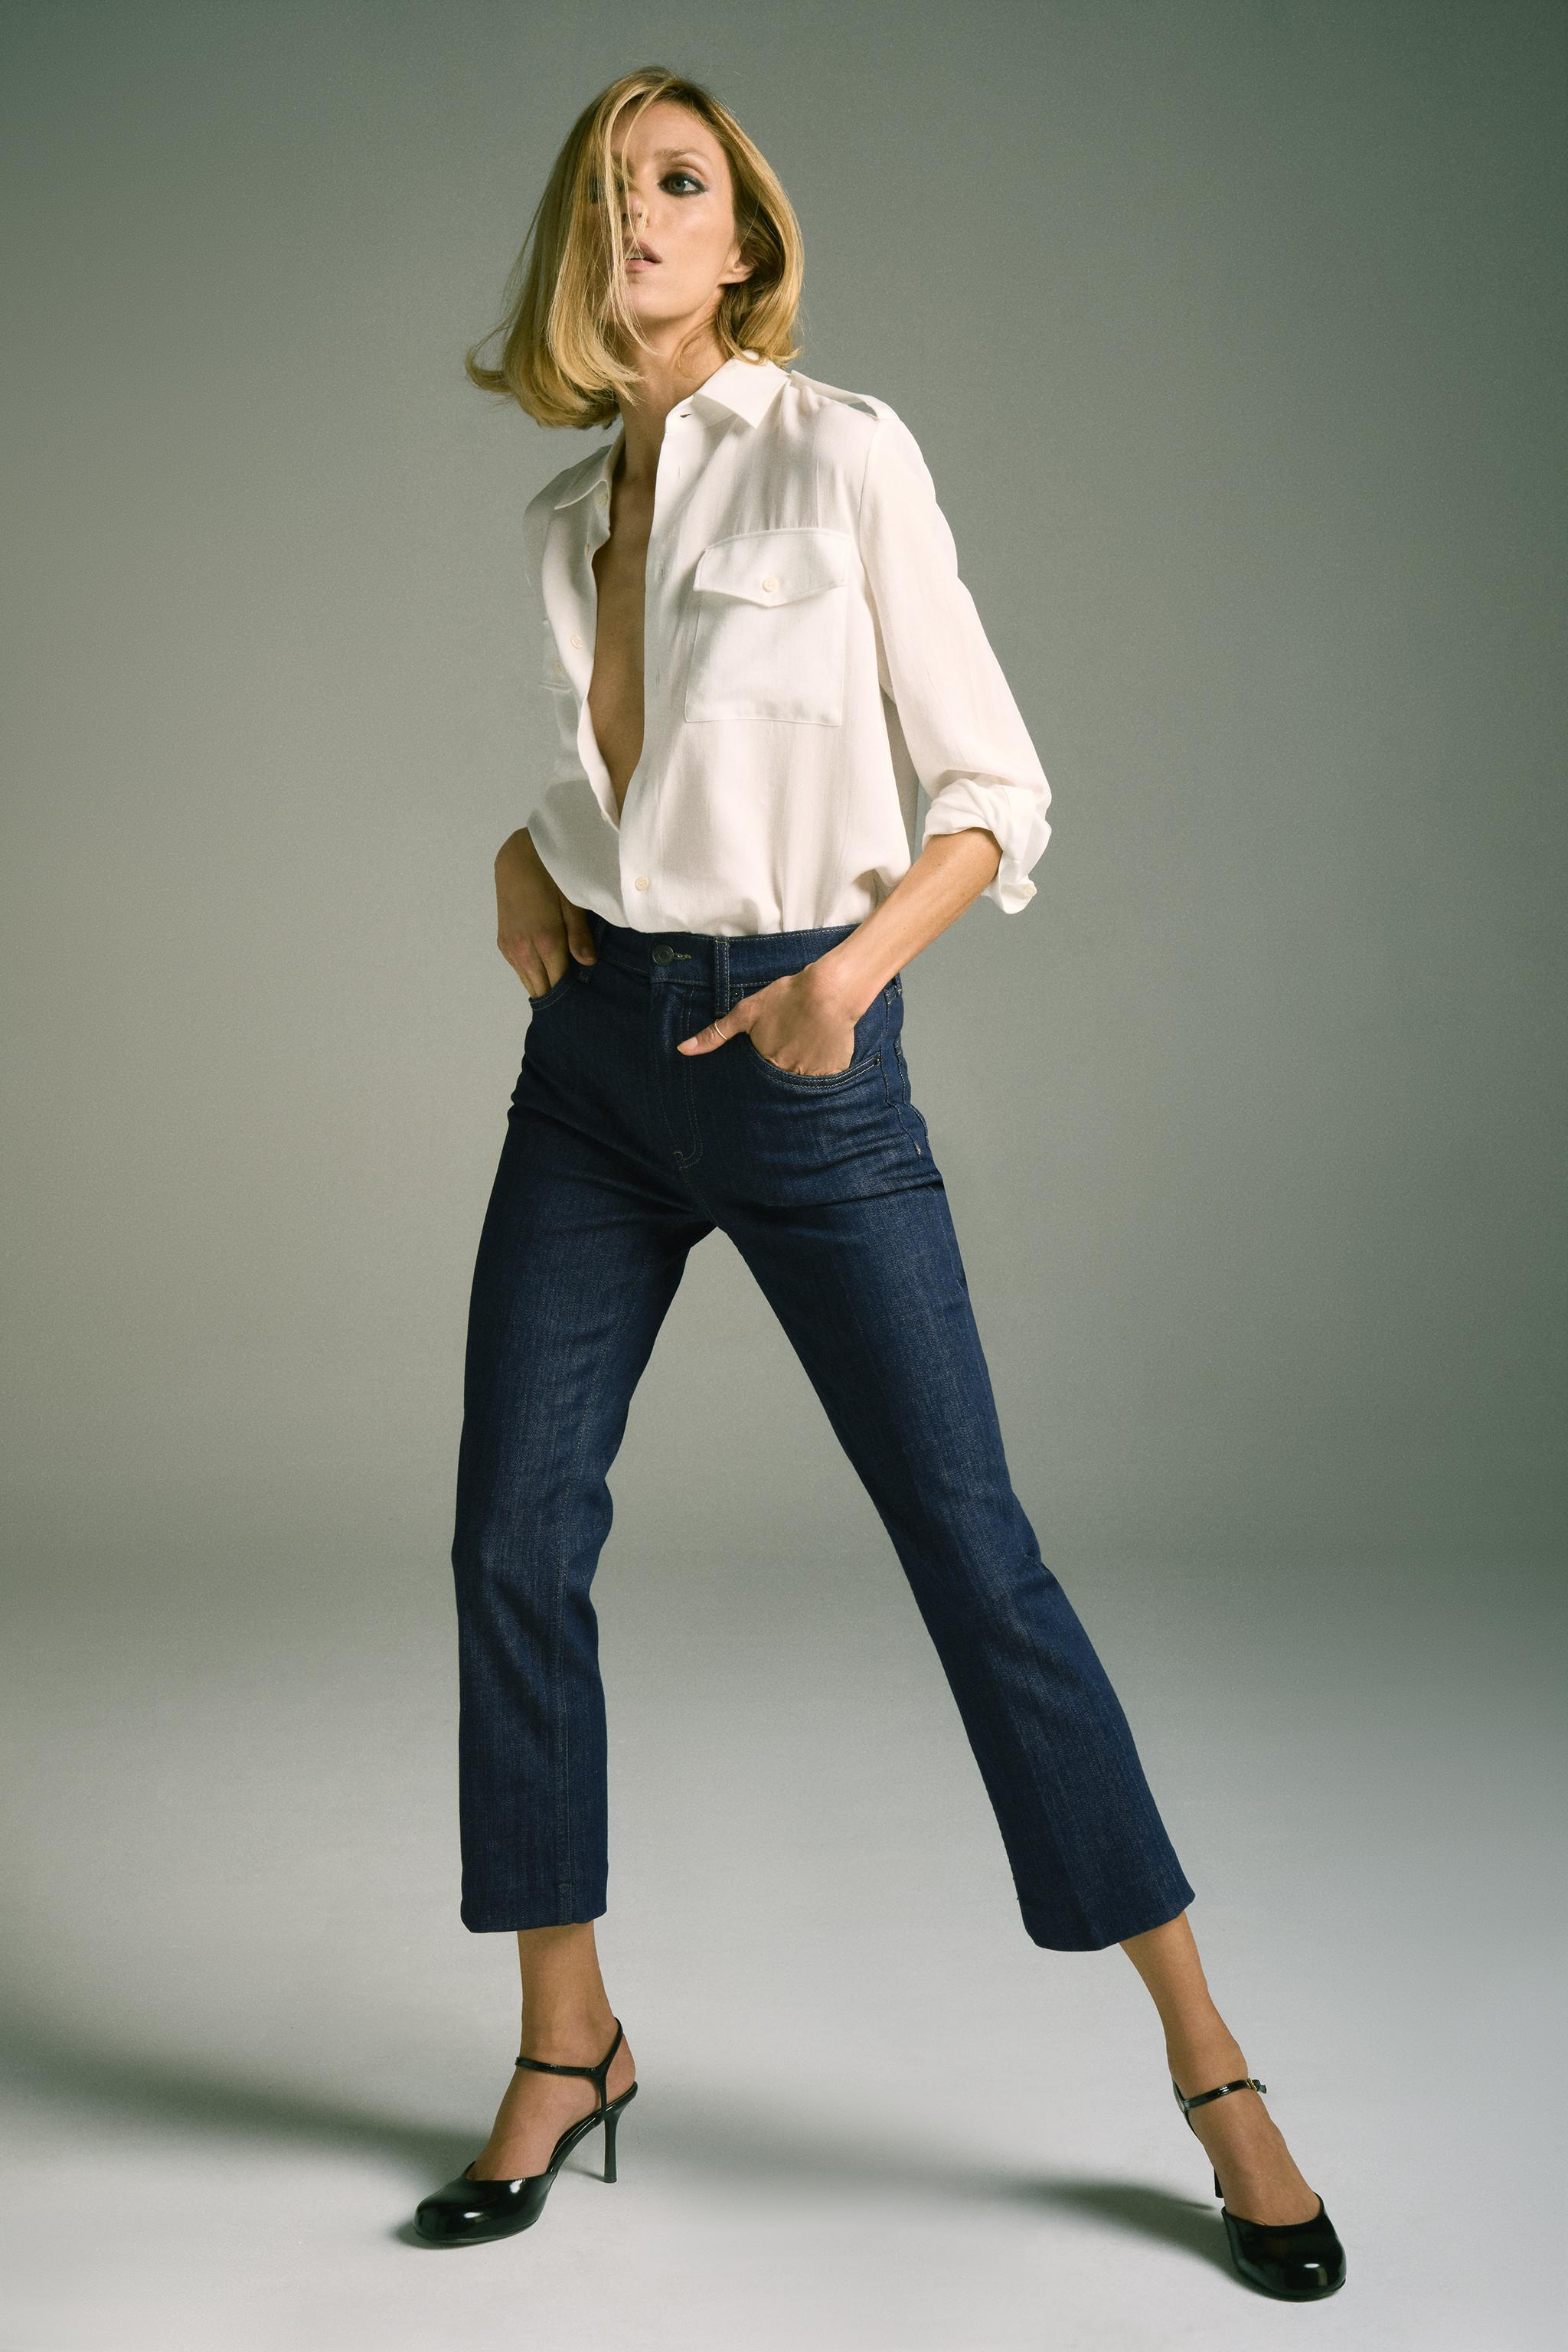

{'record_id': '2024-03_013',
 'image_path': '/Users/esosaimafidon/Documents/GitHub/how-fast-is-fashion/data/01_data_audit/raw_images/2024-03/item_013.jpg',
 'product_name': 'ZW COLLECTION HIGH WAIST CROPPED BOOTCUT JEANS',
 'month': '2024-03',
 'retailer': {'color': 'Blue',
  'category': 'jeans',
  'composition': None,
  'description': 'Slim Fit - Bootcut Leg - High Waist'},
 'raw_output': '{\n  "category": {"value": ["bottoms"], "source": "text", "confidence": 1.0},\n  "subcategory": {"value": ["bootcut_jeans"], "source": "text", "confidence": 1.0},\n  "silhouette": {"value": ["fitted"], "source": "image", "confidence": 0.9},\n  "material": {"value": ["denim"], "source": "both", "confidence": 0.7},\n  "sleeve_style": {"value": ["long_sleeve"], "source": "image", "confidence": 0.9},\n  "neckline": {"value": ["collared"], "source": "image", "confidence": 0.9},\n  "length": {"value": ["ankle"], "source": "image", "confidence": 0.9},\n  "color_profile": {"value": ["blue", "white"], "sourc

In [28]:
test_prompt("2024-03_013")